In [4]:
import pandas as pd

# 2024 Appropriation Act (signed 1 January 2024). Amounts in ₦ billions.
# Source: BudgIT 2024 budget analysis -- add the exact document title/link here
TOTAL_BUDGET = 28777  # aggregate expenditure in the signed Act (₦ billions)

data = [
    ("Security and Defense", 3880), ("Education", 2370), ("Infrastructure", 1910),
    ("Health", 1480), ("Agriculture", 1010), ("Social Development", 662),
    ("Power", 418), ("Transportation", 110), ("Communication", 29), ("Solid Minerals", 32),
]
df = (pd.DataFrame(data, columns=["Sector", "Allocation"])
        .sort_values("Allocation", ascending=False).reset_index(drop=True))

subset_total = df["Allocation"].sum()
df["Pct_of_budget"] = (df["Allocation"] / TOTAL_BUDGET * 100).round(2)
df["Pct_of_subset"] = (df["Allocation"] / subset_total * 100).round(2)
print(df.to_string(index=False))

              Sector  Allocation  Pct_of_budget  Pct_of_subset
Security and Defense        3880          13.48          32.60
           Education        2370           8.24          19.91
      Infrastructure        1910           6.64          16.05
              Health        1480           5.14          12.44
         Agriculture        1010           3.51           8.49
  Social Development         662           2.30           5.56
               Power         418           1.45           3.51
      Transportation         110           0.38           0.92
      Solid Minerals          32           0.11           0.27
       Communication          29           0.10           0.24


In [5]:
top, bottom = df.iloc[0], df.iloc[-1]
sec = df[df.Sector == "Security and Defense"].iloc[0]
edu = df[df.Sector == "Education"].iloc[0]
health = df[df.Sector == "Health"].iloc[0]

print(f"Ten sectors total: ₦{subset_total:,} bn = {subset_total / TOTAL_BUDGET * 100:.1f}% of the ₦{TOTAL_BUDGET:,} bn budget")
print(f"Highest: {top.Sector} - ₦{top.Allocation:,} bn ({top.Pct_of_budget}% of budget)")
print(f"Lowest: {bottom.Sector} - ₦{bottom.Allocation:,} bn ({bottom.Pct_of_budget}% of budget)")
print(f"Security vs Education: {sec.Pct_of_budget - edu.Pct_of_budget:.2f} percentage points higher "
      f"({(sec.Allocation / edu.Allocation - 1) * 100:.0f}% more in naira)")
print(f"Health as a share of Security: {health.Allocation / sec.Allocation * 100:.0f}%")

Ten sectors total: ₦11,901 bn = 41.4% of the ₦28,777 bn budget
Highest: Security and Defense - ₦3,880 bn (13.48% of budget)
Lowest: Communication - ₦29 bn (0.1% of budget)
Security vs Education: 5.24 percentage points higher (64% more in naira)
Health as a share of Security: 38%


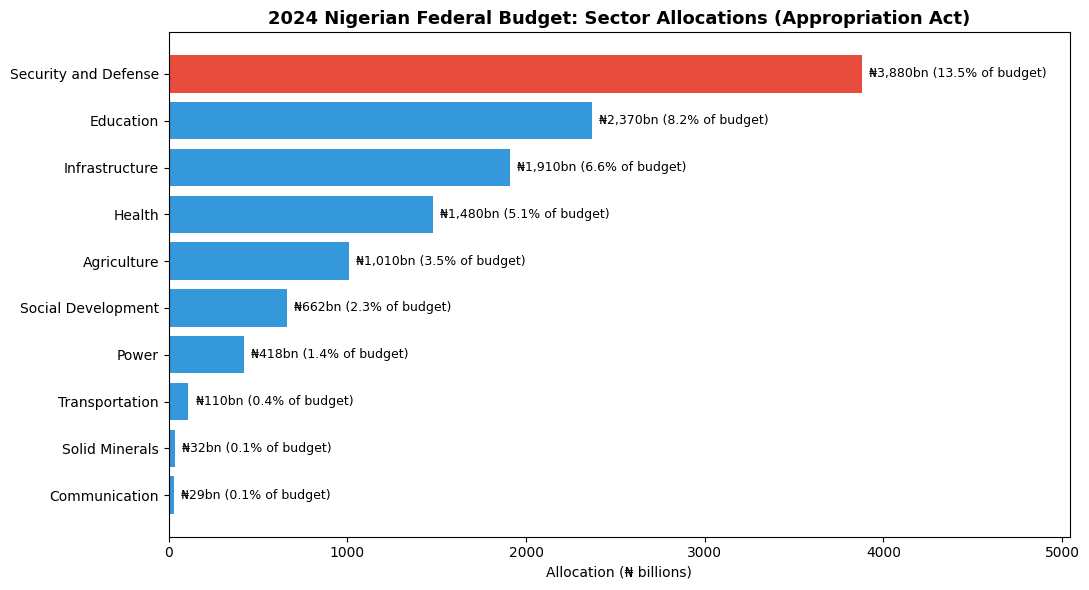

In [6]:
import os
import matplotlib.pyplot as plt

d = df.sort_values("Allocation")
colors = ["#e74c3c" if s == "Security and Defense" else "#3498db" for s in d.Sector]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(d.Sector, d.Allocation, color=colors)
for bar, pct in zip(bars, d.Pct_of_budget):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2,
            f"₦{bar.get_width():,.0f}bn ({pct:.1f}% of budget)", va="center", fontsize=9)
ax.set_xlim(0, df.Allocation.max() * 1.3)
ax.set_xlabel("Allocation (₦ billions)")
ax.set_title("2024 Nigerian Federal Budget: Sector Allocations (Appropriation Act)",
             fontsize=13, fontweight="bold")
plt.tight_layout()

os.makedirs("images", exist_ok=True)
plt.savefig("images/budget-allocations.png", dpi=150, bbox_inches="tight")
plt.show()

# 2024 Nigerian Federal Budget Analysis

**Source:** BudgIT 2024 budget analysis of the signed Appropriation Act (₦28.77 trillion). Amounts in ₦ billions.

**Scope:** Ten sectors totalling ₦11,901 billion (41.4% of the budget). All shares are of the full budget.

## Key Findings
- Security and Defense is the largest allocation: ₦3,880 billion (13.48%), 5.24 percentage points above Education (8.24%).
- Health receives 5.14%, about 38% of Security's allocation.
- Communication (0.10%) and Solid Minerals (0.11%) receive the least, which may partly reflect how spending is categorised.

## Limitations
These are planned allocations, not actual spending. Only ten sectors are covered.